In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import render
from src import postprocess as _postprocess

import types

import DriftCorrectionFunctions as DCF


smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260201_110102.log
/tmp/ipykernel_1217680/4092582263.py:29: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
folder = '/media/jbeckwith/Ezra Seagat/2p5pM_ATTO565_ATTO633/20mW638_10p561_NF_SP_1/'

In [3]:
tiff_files = H_F.file_search(folder, '.tif', '')

In [4]:
data = IO.read_tiff(tiff_files[0])

In [5]:
RGB_image, _ = sCMOS.bayer_demosaic_stack(data)

In [6]:
RGB_image = np.array(RGB_image, dtype=np.uint8)

In [7]:
filename = os.path.split(tiff_files[0])[-1]
folder = '/media/jbeckwith/Ezra Seagat/2p5pM_ATTO565_ATTO633/20mW648_10p561_NF_SP_1_RBGImages/'
IO.write_tiff(RGB_image[:, :, :, ::-1], os.path.join(folder, filename), bit=np.uint8, pixel_size=0.069, photometric='rgb')

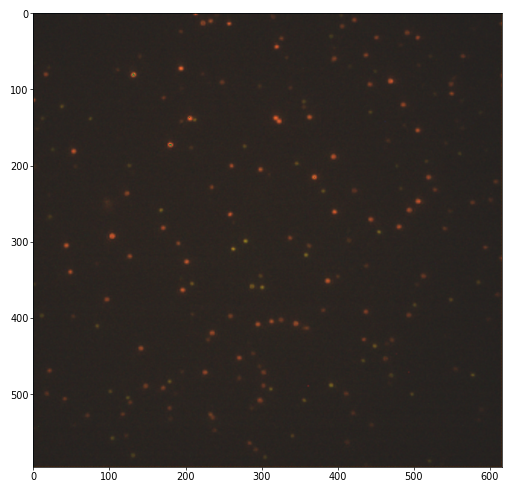

In [9]:
plt.imshow(RGB_image[0, :, :, ::-1])

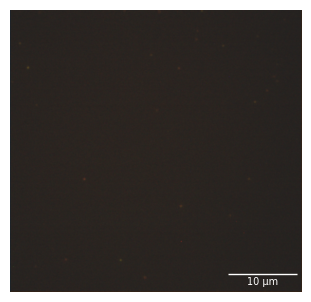

In [15]:
plotter.make_animated_gif_image(                                                                                             
      RGB_image[:200, :, :, ::-1],  # shape: (1200, H, W, 3)                                                                               
      filename='output.gif',                                                                                             
      vmin=0,                                                                                                            
      vmax=255,                                                                                                          
      pixelsize=69, 
      cbar=False,
      n_frames=200,
      scalebarlabel='10 µm',
      scalebarsize=10000
  )